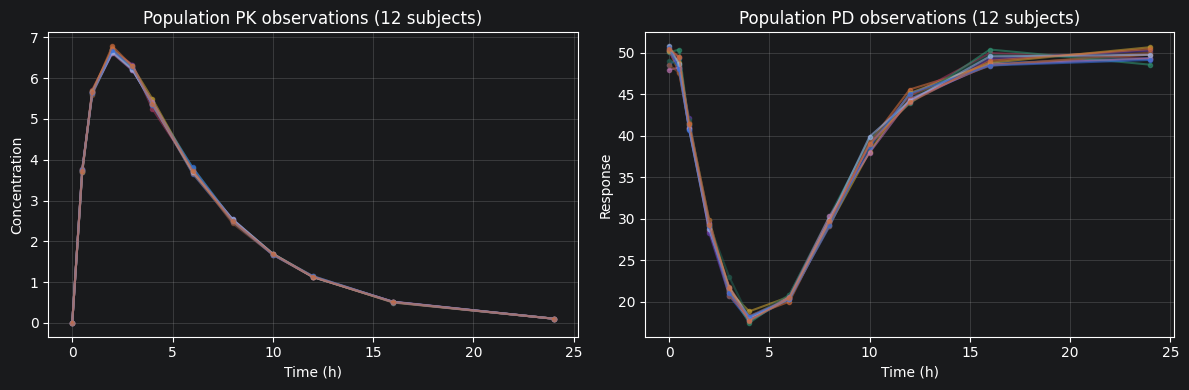

Population data ready.
pop_data shape = (144, 4)  (rows = 12 * 12)
X shape = torch.Size([144, 1]), Y shape = torch.Size([144, 1]), C_known shape = torch.Size([144, 1]), ID shape = torch.Size([144, 1])

Typical PD params (TV): {'Kin': 25.0, 'Kout': 0.5, 'Imax': 1.0, 'EC50': 4.0, 'gamma': 3.0}
First 3 sampled individual PD params:
  ID 0: Kin=25.000, Kout=0.500, Imax=1.000, EC50=4.000, gamma=3.000
  ID 1: Kin=25.000, Kout=0.500, Imax=1.000, EC50=4.000, gamma=3.000
  ID 2: Kin=25.000, Kout=0.500, Imax=1.000, EC50=4.000, gamma=3.000


In [10]:
# ============================
# Cell 1 (Population): 导入包 + 生成群体 PK/PD 数据（12个体）
# ============================
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.interpolate import interp1d

# 可复现
np.random.seed(42)
torch.manual_seed(42)

# ----------------------------
# 0) 全局设定
# ----------------------------
n_subjects = 12
t_dense = np.linspace(0, 24, 241)  # 用于数值解真值
t_obs = np.array([0, 0.5, 1, 2, 3, 4, 6, 8, 10, 12, 16, 24], dtype=float)

# PK 典型值（可视作已知机制）
tv_pk = dict(D=100.0, V=10.0, ka=1.0, ke=0.2, F=1.0)

# PD 典型值（我们希望后续识别）
tv_pd = dict(Kin=25.0, Kout=0.5, Imax=1.0, EC50=4.0, gamma=3.0)

# IIV（对数正态）标准差，表示 exp(eta), eta~N(0, omega^2)
# 可按需要调整
omega = dict(
    V=0.00, ka=0.00, ke=0.00,
    Kin=0.00, Kout=0.00, Imax=0.00, EC50=0.00
)

# 残差噪声水平
pd_noise_cv = 0.02   # 先用较小噪声
pk_noise_cv = 0.01

# ----------------------------
# 1) 个体参数采样函数
# ----------------------------
def sample_individual_params(tv_pk, tv_pd, omega):
    p = {}
    # PK
    p["D"] = tv_pk["D"]   # 剂量通常固定
    p["F"] = tv_pk["F"]
    p["V"]  = tv_pk["V"]  * np.exp(np.random.normal(0, omega["V"]))
    p["ka"] = tv_pk["ka"] * np.exp(np.random.normal(0, omega["ka"]))
    p["ke"] = tv_pk["ke"] * np.exp(np.random.normal(0, omega["ke"]))

    # 避免 ka≈ke 数值不稳定
    if abs(p["ka"] - p["ke"]) < 1e-3:
        p["ka"] = p["ke"] + 1e-3

    # PD
    p["Kin"]  = tv_pd["Kin"]  * np.exp(np.random.normal(0, omega["Kin"]))
    p["Kout"] = tv_pd["Kout"] * np.exp(np.random.normal(0, omega["Kout"]))
    p["Imax"] = tv_pd["Imax"] * np.exp(np.random.normal(0, omega["Imax"]))
    p["EC50"] = tv_pd["EC50"] * np.exp(np.random.normal(0, omega["EC50"]))
    p["gamma"] = tv_pd["gamma"]  # 先固定

    # 约束到合理范围
    p["Imax"] = np.clip(p["Imax"], 0.05, 1.5)
    p["EC50"] = max(p["EC50"], 1e-3)
    p["Kout"] = max(p["Kout"], 1e-4)
    p["Kin"]  = max(p["Kin"], 1e-4)
    return p

# ----------------------------
# 2) 用个体参数生成 C(t), R(t)
# ----------------------------
all_rows = []          # 每行: [ID, t, C_obs, R_obs]
subject_params = []    # 保存真实个体参数，后面评估用

for sid in range(n_subjects):
    p = sample_individual_params(tv_pk, tv_pd, omega)
    subject_params.append(p)

    # PK: Bateman
    pre = (p["F"] * p["D"] * p["ka"]) / (p["V"] * (p["ka"] - p["ke"]))
    C_dense = pre * (np.exp(-p["ke"] * t_dense) - np.exp(-p["ka"] * t_dense))
    C_dense = np.clip(C_dense, 0.0, None)
    C_func = interp1d(t_dense, C_dense, kind="cubic", fill_value="extrapolate")

    # PD ODE
    def pd_ode(R, t):
        C_t = max(float(C_func(t)), 1e-8)
        hill = (C_t**p["gamma"]) / (p["EC50"]**p["gamma"] + C_t**p["gamma"])
        return p["Kin"] - (p["Kin"] * p["Imax"]) * hill - p["Kout"] * R

    R0 = p["Kin"] / p["Kout"]  # 个体基线
    R_dense = odeint(lambda r, tt: pd_ode(r, tt), R0, t_dense).flatten()

    # 观测点
    C_obs_clean = C_func(t_obs)
    R_obs_clean = interp1d(t_dense, R_dense, kind="cubic")(t_obs)

    # 加噪声（比例噪声）
    C_obs = C_obs_clean * (1.0 + np.random.normal(0, pk_noise_cv, size=t_obs.shape))
    R_obs = R_obs_clean * (1.0 + np.random.normal(0, pd_noise_cv, size=t_obs.shape))

    C_obs = np.clip(C_obs, 0.0, None)

    for j, tt in enumerate(t_obs):
        all_rows.append([sid, tt, C_obs[j], R_obs[j]])

pop_data = np.array(all_rows, dtype=float)  # [N,4], N=12*12=144

# ----------------------------
# 3) 组装训练变量（先按你后面最小改造需求）
# ----------------------------
# 注意：目前先不加个体ID到网络输入，先做“pooled”版本
# X: time, Y: response, C_known: concentration (known input for library)
X_np = pop_data[:, 1:2]        # time
C_obs_np = pop_data[:, 2:3]    # observed C
Y_np = pop_data[:, 3:4]        # observed R
ID_np = pop_data[:, 0:1].astype(int)

X = torch.tensor(X_np, dtype=torch.float32)
Y = torch.tensor(Y_np, dtype=torch.float32)
C_known = torch.tensor(C_obs_np, dtype=torch.float32)
ID_tensor = torch.tensor(ID_np, dtype=torch.long)

# ----------------------------
# 4) 可视化
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for sid in range(n_subjects):
    idx = (ID_np[:, 0] == sid)
    axes[0].plot(X_np[idx, 0], C_obs_np[idx, 0], '.-', alpha=0.6)
    axes[1].plot(X_np[idx, 0], Y_np[idx, 0], '.-', alpha=0.6)

axes[0].set_title(f"Population PK observations ({n_subjects} subjects)")
axes[0].set_xlabel("Time (h)")
axes[0].set_ylabel("Concentration")
axes[0].grid(alpha=0.3)

axes[1].set_title(f"Population PD observations ({n_subjects} subjects)")
axes[1].set_xlabel("Time (h)")
axes[1].set_ylabel("Response")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Population data ready.")
print(f"pop_data shape = {pop_data.shape}  (rows = {n_subjects} * {len(t_obs)})")
print(f"X shape = {X.shape}, Y shape = {Y.shape}, C_known shape = {C_known.shape}, ID shape = {ID_tensor.shape}")

print("\nTypical PD params (TV):", tv_pd)
print("First 3 sampled individual PD params:")
for i in range(min(3, n_subjects)):
    p = subject_params[i]
    print(f"  ID {i}: Kin={p['Kin']:.3f}, Kout={p['Kout']:.3f}, Imax={p['Imax']:.3f}, EC50={p['EC50']:.3f}, gamma={p['gamma']:.3f}")

In [11]:
# ============================
# Cell 2 : DeePyMoD数据封装 + 最小PD库
# Theta = [1, Hill(C), R]
# ============================
import torch
import torch.nn as nn
from torch.autograd import grad
from typing import Tuple

from deepymod import Library
from deepymod.data import Dataset, get_train_test_loader
from deepymod.utils.types import TensorList

# ---- 1) 手动标准化 ----
x_mean, x_std = X.mean(), X.std()
y_mean, y_std = Y.mean(), Y.std()

Xn = (X - x_mean) / (x_std + 1e-8)
Yn = (Y - y_mean) / (y_std + 1e-8)

# C 不做 z-score，保留原始物理浓度
C_raw = C_known.clone()

print("Normalized tensors:")
print(f"Xn: mean={Xn.mean().item():.4f}, std={Xn.std().item():.4f}")
print(f"Yn: mean={Yn.mean().item():.4f}, std={Yn.std().item():.4f}")
print(f"C_raw: min={C_raw.min().item():.4f}, max={C_raw.max().item():.4f}")

# ---- 2) Dataset ----
def load_population_data_for_deepymod():
    return Xn.float(), Yn.float()

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

dataset = Dataset(
    load_population_data_for_deepymod,
    preprocess_kwargs={
        "noise_level": 0.0,
        "normalize_coords": False,
        "normalize_data": False,
    },
    device=device
)
train_loader, test_loader = get_train_test_loader(dataset, train_test_split=0.8)

# ---- 3) Known C(t) 模块（按时间最近邻匹配）----
class KnownCFromTime(nn.Module):
    def __init__(self, Xn_ref: torch.Tensor, Cn_ref: torch.Tensor):
        super().__init__()
        self.register_buffer("Xref", Xn_ref.detach().clone())  # [N,1]
        self.register_buffer("Cref", Cn_ref.detach().clone())  # [N,1]

    def forward(self, x_query: torch.Tensor):
        # x_query [B,1], Xref [N,1]
        dist = torch.abs(x_query - self.Xref.T)  # [B,N]
        idx = torch.argmin(dist, dim=1)          # [B]
        c = self.Cref[idx]                       # [B,1]
        return c

known_c_module = KnownCFromTime(Xn.to(device), C_raw.to(device)).to(device)

# ---- 4) 最小PD库 ----
class PDLibraryMinimal(Library):
    def __init__(self, known_c: nn.Module):
        super().__init__()
        self.known_c = known_c
        # 用更接近真值的初始化更稳
        self.raw_ec50 = nn.Parameter(torch.tensor(4.0))  # softplus(4)≈4.018
        self.raw_gamma = nn.Parameter(torch.tensor(2.5)) # softplus(2.5)≈2.58

    def library(self, input):
        prediction, data = input
        R = prediction[:, 0:1]

        dRdt = grad(
            R, data,
            grad_outputs=torch.ones_like(R),
            create_graph=True,
            retain_graph=True
        )[0][:, 0:1]

        C = self.known_c(data).clamp_min(1e-8)  # 物理浓度域
        ec50 = torch.nn.functional.softplus(self.raw_ec50)
        gamma = torch.nn.functional.softplus(self.raw_gamma)

        hill = (C ** gamma) / (ec50 ** gamma + C ** gamma)

        one = torch.ones_like(R)
        theta = torch.cat([one, hill, R], dim=1)
        return [dRdt], [theta]

library = PDLibraryMinimal(known_c_module).to(device)

# ---- 5) 正确调试：pred 必须来自 data 的函数 ----
tmp_net = nn.Sequential(
    nn.Linear(1, 16), nn.Tanh(),
    nn.Linear(16, 16), nn.Tanh(),
    nn.Linear(16, 1)
).to(device)

for xb, yb in train_loader:
    xb = xb.to(device).requires_grad_(True)  # 必须 requires_grad
    pred = tmp_net(xb)                       # pred = f(xb) 才能对 xb 求导
    dts, thetas = library((pred, xb))
    print("Debug shapes:")
    print("  xb:", xb.shape, "pred:", pred.shape)
    print("  dRdt:", dts[0].shape, "theta:", thetas[0].shape)  # [B,1], [B,3]
    break

print("Cell 2 ready.")

Normalized tensors:
Xn: mean=-0.0000, std=1.0000
Yn: mean=-0.0000, std=1.0000
C_raw: min=0.0000, max=6.7860
Device: cuda
Preprocessing data
Dataset is using device:  cuda
Debug shapes:
  xb: torch.Size([115, 1]) pred: torch.Size([115, 1])
  dRdt: torch.Size([115, 1]) theta: torch.Size([115, 3])
Cell 2 ready.


In [12]:
# ============================
# Cell 3 (revised): 更稳的最小训练策略
# ============================
import torch
import torch.nn as nn
from deepymod import DeepMoD
from deepymod.model.func_approx import NN
from deepymod.model.sparse_estimators import Threshold
import torch.nn.functional as F

# ---- 1) Ridge ----
class Ridge(nn.Module):
    def __init__(self, lam=1e-3):
        super().__init__()
        self.lam = lam
        self.sparsity_masks = None
        self.coeff_vectors = None

    def forward(self, input):
        time_derivs, thetas = input
        if self.sparsity_masks is None:
            self.sparsity_masks = [
                torch.ones(theta.shape[1], dtype=torch.bool, device=theta.device)
                for theta in thetas
            ]

        sparse_thetas = [theta[:, mask] for theta, mask in zip(thetas, self.sparsity_masks)]

        coeff_vectors_sparse = []
        for theta_s, dt in zip(sparse_thetas, time_derivs):
            XtX = theta_s.T @ theta_s
            reg = self.lam * torch.eye(XtX.shape[0], device=XtX.device)
            Xty = theta_s.T @ dt
            try:
                w = torch.linalg.solve(XtX + reg, Xty)
            except RuntimeError:
                w = torch.linalg.pinv(XtX + reg) @ Xty
            coeff_vectors_sparse.append(w)

        full_coeffs = []
        for mask, w in zip(self.sparsity_masks, coeff_vectors_sparse):
            full = torch.zeros((mask.shape[0], 1), device=w.device)
            full[mask] = w
            full_coeffs.append(full)

        self.coeff_vectors = full_coeffs
        return full_coeffs

# ---- 2) model ----
network = NN(1, [64, 64, 64], 1).to(device)   # 稍增容量
estimator = Threshold(0.03)                    # 阈值略保守
constraint = Ridge(lam=1e-3)

model = DeepMoD(network, library, estimator, constraint).to(device)

optimizer_nn = torch.optim.Adam(model.func_approx.parameters(), lr=5e-4)
optimizer_lib = torch.optim.Adam(model.library.parameters(), lr=5e-5)

print("Init ec50,gamma:",
      F.softplus(model.library.raw_ec50).item(),
      F.softplus(model.library.raw_gamma).item())

# ---- 3) util ----
def eval_mse(model, loader):
    model.eval()
    val = 0.0
    n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred, _ = model.func_approx(xb)
            val += torch.mean((pred - yb) ** 2).item()
            n += 1
    model.train()
    return val / max(n, 1)

# ---- 4) Stage A: strong pretrain NN ----
def pretrain_nn(model, train_loader, test_loader, n_epochs=4000):
    for p in model.library.parameters():
        p.requires_grad = False
    for p in model.func_approx.parameters():
        p.requires_grad = True

    best = 1e9
    bad = 0
    for ep in range(n_epochs):
        total = 0.0
        nb = 0
        for xb, yb in train_loader:
            xb = xb.to(device).requires_grad_(True)
            yb = yb.to(device)
            pred, _ = model.func_approx(xb)
            mse = torch.mean((pred - yb) ** 2)

            optimizer_nn.zero_grad()
            mse.backward()
            optimizer_nn.step()

            total += mse.item()
            nb += 1

        if ep % 200 == 0:
            tr = total / nb
            te = eval_mse(model, test_loader)
            print(f"[Pretrain] ep={ep}, train={tr:.4e}, val={te:.4e}")

        # 简单早停
        te = eval_mse(model, test_loader)
        if te < best - 1e-5:
            best = te
            bad = 0
        else:
            bad += 1
        if bad > 300:
            print(f"[Pretrain] early stop at ep={ep}, best_val={best:.4e}")
            break

# ---- 5) Stage B: alternating ----
def alternating_train(
    model, train_loader, test_loader,
    n_outer=8, n_inner=200,
    lambda_reg_start=0.02, lambda_reg_end=0.20,
    lambda_gamma=1e-3
):
    for outer in range(n_outer):
        print(f"\n[Outer {outer+1}/{n_outer}]")

        # 线性增大 reg 权重（关键）
        alpha = outer / max(n_outer - 1, 1)
        lambda_reg = lambda_reg_start * (1 - alpha) + lambda_reg_end * alpha

        # (1) NN 微调
        for p in model.library.parameters():
            p.requires_grad = False
        for p in model.func_approx.parameters():
            p.requires_grad = True

        for _ in range(200):
            for xb, yb in train_loader:
                xb = xb.to(device).requires_grad_(True)
                yb = yb.to(device)
                pred, _ = model.func_approx(xb)
                mse = torch.mean((pred - yb) ** 2)
                optimizer_nn.zero_grad()
                mse.backward()
                optimizer_nn.step()

        # (2) 更新稀疏 mask
        with torch.enable_grad():
            for xb, yb in train_loader:
                xb = xb.to(device).requires_grad_(True)
                pred, dts, ths = model(xb)
                break
            masks = estimator(ths, dts)
            model.constraint.sparsity_masks = masks

        # (3) 固定NN，更新库参数
        for p in model.func_approx.parameters():
            p.requires_grad = False
        for p in model.library.parameters():
            p.requires_grad = True

        for inner in range(n_inner):
            total_loss, total_mse, total_reg = 0.0, 0.0, 0.0
            nb = 0
            for xb, yb in train_loader:
                xb = xb.to(device).requires_grad_(True)
                yb = yb.to(device)

                pred, dts, ths = model(xb)
                mse = torch.mean((pred - yb) ** 2)

                coeffs = model.constraint_coeffs(sparse=True, scaled=False)
                reg = torch.mean(torch.stack([
                    torch.mean((dt - th @ cf) ** 2)
                    for dt, th, cf in zip(dts, ths, coeffs)
                ]))

                # 轻微约束 gamma 不要塌得过低（仅正则，不是硬限制）
                gamma_now = F.softplus(model.library.raw_gamma)

                loss = mse + lambda_reg * reg + lambda_gamma * gamma_now

                optimizer_lib.zero_grad()
                loss.backward()
                optimizer_lib.step()

                total_loss += loss.item()
                total_mse += mse.item()
                total_reg += reg.item()
                nb += 1

            if inner == n_inner - 1:
                print(f"  [Inner End] lambda_reg={lambda_reg:.3f} | "
                      f"loss={total_loss/nb:.4e} | mse={total_mse/nb:.4e} | reg={total_reg/nb:.4e}")

        val = eval_mse(model, test_loader)
        ec50_now = F.softplus(model.library.raw_ec50).item()
        gamma_now = F.softplus(model.library.raw_gamma).item()
        print(f"  [Val] mse={val:.4e}")
        print(f"  [Lib] ec50={ec50_now:.4f}, gamma={gamma_now:.4f}")
        print(f"  [Mask] {model.constraint.sparsity_masks[0].detach().cpu().numpy()}")

print("Start revised pretraining...")
pretrain_nn(model, train_loader, test_loader, n_epochs=4000)

print("\nStart revised alternating...")
alternating_train(
    model, train_loader, test_loader,
    n_outer=8, n_inner=200,
    lambda_reg_start=0.02, lambda_reg_end=0.20,  # 关键
    lambda_gamma=1e-3
)

print("\nCell 3 revised training done.")

Init ec50,gamma: 4.0181498527526855 2.578889846801758
Start revised pretraining...
[Pretrain] ep=0, train=1.0197e+00, val=1.0385e+00
[Pretrain] ep=200, train=1.0379e-02, val=5.6280e-03
[Pretrain] ep=400, train=8.9323e-03, val=4.4845e-03
[Pretrain] ep=600, train=7.3965e-03, val=3.8594e-03
[Pretrain] ep=800, train=5.8393e-03, val=3.9545e-03
[Pretrain] ep=1000, train=4.7469e-03, val=4.6127e-03
[Pretrain] early stop at ep=1118, best_val=3.6667e-03

Start revised alternating...

[Outer 1/8]
  [Inner End] lambda_reg=0.020 | loss=1.9450e-02 | mse=3.8063e-03 | reg=6.5276e-01
  [Val] mse=4.2229e-03
  [Lib] ec50=4.0279, gamma=2.5881
  [Mask] [ True  True  True]

[Outer 2/8]
  [Inner End] lambda_reg=0.046 | loss=2.5768e-02 | mse=2.8957e-03 | reg=4.4343e-01
  [Val] mse=3.3303e-03
  [Lib] ec50=4.0416, gamma=2.6011
  [Mask] [ True  True  True]

[Outer 3/8]
  [Inner End] lambda_reg=0.071 | loss=5.4304e-02 | mse=2.4125e-03 | reg=6.8989e-01
  [Val] mse=2.6449e-03
  [Lib] ec50=4.0560, gamma=2.6142
  [Ma

In [13]:
# ============================
# Cell 4: 从 DeePyMoD 模型解码 PK/PD 参数 + 与真值对比
# 依赖：Cell 1~3 已运行，变量 model, x_std, y_std, y_mean, tv_pd 已存在
# ============================
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

# ---- 1) 读取稀疏系数 ----
# 模型形式（在标准化坐标/响应下）:
#   d(y_n)/d(x_n) = a0 + a1 * Hill(C) + a2 * y_n
coeff_full = model.constraint.coeff_vectors[0].detach().cpu().numpy().flatten()
a0, a1, a2 = coeff_full

print("Raw discovered coeffs (normalized system):")
print(f"  a0={a0:.6f}, a1={a1:.6f}, a2={a2:.6f}")

# mask 信息
if model.constraint.sparsity_masks is not None:
    mask = model.constraint.sparsity_masks[0].detach().cpu().numpy().astype(int)
    print(f"  mask=[1, Hill, R] -> {mask.tolist()}")
else:
    mask = np.array([1, 1, 1], dtype=int)
    print("  mask not set, fallback to all-ones.")

# ---- 2) 从标准化方程还原到物理方程 ----
# 关系：
#   y_n = (R - y_mean)/y_std
#   x_n = (t - x_mean)/x_std
#   dR/dt = A + B*Hill(C) + C*R
#
# 推导结果：
#   A = (y_std/x_std) * (a0 - a2*(y_mean/y_std))
#   B = (y_std/x_std) * a1
#   C = a2 / x_std
x_std_val = float(x_std.item())
y_std_val = float(y_std.item())
y_mean_val = float(y_mean.item())

A = (y_std_val / x_std_val) * (a0 - a2 * (y_mean_val / y_std_val))
B = (y_std_val / x_std_val) * a1
Ccoef = a2 / x_std_val

# 对应目标结构：
# dR/dt = Kin - Kin*Imax*Hill(C) - Kout*R
Kin_hat = A
Kout_hat = -Ccoef
Imax_hat = np.nan if abs(Kin_hat) < 1e-12 else (-B / Kin_hat)

# 库中可学习参数
EC50_hat = float(F.softplus(model.library.raw_ec50).item())
gamma_hat = float(F.softplus(model.library.raw_gamma).item())

# 合理性约束（仅展示时处理）
Kin_hat_clip = max(Kin_hat, 1e-8)
Kout_hat_clip = max(Kout_hat, 1e-8)
Imax_hat_clip = float(np.clip(Imax_hat, 0.0, 2.0)) if np.isfinite(Imax_hat) else np.nan

print("\nDecoded physical params:")
print(f"  Kin_hat   = {Kin_hat:.6f}")
print(f"  Kout_hat  = {Kout_hat:.6f}")
print(f"  Imax_hat  = {Imax_hat:.6f}")
print(f"  EC50_hat  = {EC50_hat:.6f}")
print(f"  gamma_hat = {gamma_hat:.6f}")

# ---- 3) 与真值比较 ----
true = tv_pd
cmp_df = pd.DataFrame([
    {"param": "Kin",   "true": true["Kin"],   "est": Kin_hat,   "est_clip": Kin_hat_clip},
    {"param": "Kout",  "true": true["Kout"],  "est": Kout_hat,  "est_clip": Kout_hat_clip},
    {"param": "Imax",  "true": true["Imax"],  "est": Imax_hat,  "est_clip": Imax_hat_clip},
    {"param": "EC50",  "true": true["EC50"],  "est": EC50_hat,  "est_clip": EC50_hat},
    {"param": "gamma", "true": true["gamma"], "est": gamma_hat, "est_clip": gamma_hat},
])

cmp_df["rel_err_%"] = (cmp_df["est"] - cmp_df["true"]) / cmp_df["true"] * 100.0

print("\n=== Parameter comparison ===")
print(cmp_df.to_string(index=False))

# ---- 4) 额外输出：供后续NLME作为初值 ----
deepymod_init_one = {
    "Kin0_dm": float(Kin_hat_clip),
    "Kout0_dm": float(Kout_hat_clip),
    "Imax0_dm": float(Imax_hat_clip if np.isfinite(Imax_hat_clip) else 1.0),
    "EC50_0_dm": float(max(EC50_hat, 1e-8)),
    "gamma_0_dm": float(max(gamma_hat, 0.2)),
    "mask_1": int(mask[0]),
    "mask_Hill": int(mask[1]),
    "mask_R": int(mask[2]),
}
print("\nDeePyMoD init (for NLME):")
print(deepymod_init_one)

Raw discovered coeffs (normalized system):
  a0=4.183128, a1=-15.853774, a2=-3.389602
  mask=[1, Hill, R] -> [1, 1, 1]

Decoded physical params:
  Kin_hat   = 24.923260
  Kout_hat  = 0.484722
  Imax_hat  = 1.081896
  EC50_hat  = 4.127531
  gamma_hat = 2.680207

=== Parameter comparison ===
param  true       est  est_clip  rel_err_%
  Kin  25.0 24.923260 24.923260  -0.306961
 Kout   0.5  0.484722  0.484722  -3.055596
 Imax   1.0  1.081896  1.081896   8.189583
 EC50   4.0  4.127531  4.127531   3.188276
gamma   3.0  2.680207  2.680207 -10.659782

DeePyMoD init (for NLME):
{'Kin0_dm': 24.923259735107422, 'Kout0_dm': 0.4847220182418823, 'Imax0_dm': 1.0818958282470703, 'EC50_0_dm': 4.127531051635742, 'gamma_0_dm': 2.680206537246704, 'mask_1': 1, 'mask_Hill': 1, 'mask_R': 1}


In [22]:
# ============================
# Cell 5: 启动 MATLAB 引擎
#验证 engine 安装是否正确
#验证变量传递是否正确
#验证你可以从 notebook 直接跑 MATLAB 代码
# ============================
import matlab.engine
import matlab

eng = matlab.engine.start_matlab()

# 1) 把变量送进 MATLAB workspace
eng.workspace["sid"]   = matlab.double((df["sid"].values.astype(float)+1).reshape(-1,1).tolist())
eng.workspace["time"]  = matlab.double(df["time"].values.astype(float).reshape(-1,1).tolist())
eng.workspace["conc"]  = matlab.double(df["C_obs"].values.astype(float).reshape(-1,1).tolist())
eng.workspace["resp"]  = matlab.double(df["R_obs"].values.astype(float).reshape(-1,1).tolist())

eng.workspace["Kin0"]   = float(deepymod_init_one["Kin0_dm"])
eng.workspace["Kout0"]  = float(deepymod_init_one["Kout0_dm"])
eng.workspace["Imax0"]  = float(deepymod_init_one["Imax0_dm"])
eng.workspace["EC500"]  = float(deepymod_init_one["EC50_0_dm"])
eng.workspace["gamma0"] = float(deepymod_init_one["gamma_0_dm"])

# 2) 直接在 MATLAB 执行脚本片段
eng.eval("""
nObs = numel(resp);
nSub = numel(unique(sid));
ok = true;
msg = 'inline MATLAB execution works';

Kin_pop = Kin0;
Kout_pop = Kout0;
Imax = Imax0;
EC50 = EC500;
gamma = gamma0;
""", nargout=0)

# 3) 取回结果
nObs = eng.workspace["nObs"]
nSub = eng.workspace["nSub"]
msg  = eng.workspace["msg"]
Kin_pop = eng.workspace["Kin_pop"]

print("msg:", msg)
print("nObs:", nObs, "nSub:", nSub, "Kin_pop:", Kin_pop)


msg: inline MATLAB execution works
nObs: 144.0 nSub: 12.0 Kin_pop: 24.923259735107422


In [23]:
# ============================
# Cell 6: 创建matlab函数
# ============================

from pathlib import Path

m_code = r"""
function out = run_nlme_from_python(sid, time, conc, resp, Kin0, Kout0, Imax0, EC500, gamma0)
% Minimal ODE fit in MATLAB, callable from Python engine.
% Estimate Kin_pop, Kout_pop with fixed Imax/EC50/gamma via fminsearch.

sid  = sid(:);
time = time(:);
conc = conc(:);
resp = resp(:);

Imax = Imax0;
EC50 = EC500;
gamma = gamma0;

% objective
obj = @(th) sse_obj(th, sid, time, conc, resp, Imax, EC50, gamma);

theta0 = [max(Kin0,1e-6), max(Kout0,1e-6)];
opts = optimset('Display','off','MaxIter',200,'TolX',1e-6,'TolFun',1e-6);
[theta_hat, fval, exitflag] = fminsearch(obj, theta0, opts);

Kin_hat = max(theta_hat(1), 1e-8);
Kout_hat = max(theta_hat(2), 1e-8);

% final prediction
yhat = predict_all(Kin_hat, Kout_hat, sid, time, conc, Imax, EC50, gamma);
rmse = sqrt(mean((resp - yhat).^2));

out = struct();
out.ok = true;
out.exitflag = exitflag;
out.fval = fval;
out.nObs = numel(resp);
out.nSub = numel(unique(sid));
out.Kin_pop = Kin_hat;
out.Kout_pop = Kout_hat;
out.Imax = Imax;
out.EC50 = EC50;
out.gamma = gamma;
out.rmse = rmse;
end

function val = sse_obj(th, sid, time, conc, resp, Imax, EC50, gamma)
Kin = max(th(1), 1e-8);
Kout = max(th(2), 1e-8);
yhat = predict_all(Kin, Kout, sid, time, conc, Imax, EC50, gamma);
res = resp - yhat;
val = sum(res.^2);
end

function yhat = predict_all(Kin, Kout, sid, time, conc, Imax, EC50, gamma)
yhat = zeros(size(time));
uids = unique(sid);

for k = 1:numel(uids)
    id = uids(k);
    idx = find(sid == id);

    tk = time(idx);
    ck = conc(idx);

    [tk_s, ord] = sort(tk);
    ck_s = ck(ord);

    cfun = @(tt) interp1(tk_s, ck_s, tt, 'linear', 'extrap');
    rhs = @(tt, R) Kin ...
        - (Kin * Imax) * ((max(cfun(tt),1e-10)^gamma) / (EC50^gamma + max(cfun(tt),1e-10)^gamma)) ...
        - Kout * R;

    R0 = Kin / Kout;
    [~, Rsol] = ode45(rhs, tk_s, R0);

    yk = Rsol(:);
    ytmp = zeros(size(tk));
    ytmp(ord) = yk;
    yhat(idx) = ytmp;
end
end
"""

m_path = Path.cwd() / "run_nlme_from_python.m"
m_path.write_text(m_code, encoding="utf-8")
print("Saved:", m_path)

Saved: D:\PycharmProjects\DeePyMoD\DeePyNamics\run_nlme_from_python.m


In [24]:
# ============================
# Cell 7: 调用函数进行nlmefit
# ============================
import os
eng.addpath(os.getcwd(), nargout=0)

out = eng.run_nlme_from_python(
    eng.workspace["sid"],
    eng.workspace["time"],
    eng.workspace["conc"],
    eng.workspace["resp"],
    eng.workspace["Kin0"],
    eng.workspace["Kout0"],
    eng.workspace["Imax0"],
    eng.workspace["EC500"],
    eng.workspace["gamma0"],
    nargout=1
)

print(out)

{'ok': True, 'exitflag': 1.0, 'fval': 105.77748737820652, 'nObs': 144.0, 'nSub': 12.0, 'Kin_pop': 25.663787335543045, 'Kout_pop': 0.5076024927583815, 'Imax': 1.0818958282470703, 'EC50': 4.127531051635742, 'gamma': 2.680206537246704, 'rmse': 0.857068191319033}


In [25]:
# ============================
# Cell 8: 升级版 MATLAB 拟合（估计 Kin, Kout, EC50）
# 固定 Imax, gamma
# 说明：会先在当前目录覆盖写入 run_nlme_from_python.m（3参数版）
# ============================
from pathlib import Path
import os
import matlab.engine

# ---------- 1) 写入升级版 .m ----------
m_code = r"""
function out = run_nlme_from_python(sid, time, conc, resp, Kin0, Kout0, Imax0, EC500, gamma0)
% Upgrade version:
% Estimate [Kin_pop, Kout_pop, EC50_pop], fix Imax/gamma.

sid  = sid(:);
time = time(:);
conc = conc(:);
resp = resp(:);

Imax = Imax0;
gamma = gamma0;

obj = @(th) sse_obj(th, sid, time, conc, resp, Imax, gamma);

theta0 = [max(Kin0,1e-6), max(Kout0,1e-6), max(EC500,1e-6)];
opts = optimset('Display','off','MaxIter',300,'TolX',1e-7,'TolFun',1e-7);

[theta_hat, fval, exitflag] = fminsearch(obj, theta0, opts);

Kin_hat  = max(theta_hat(1), 1e-8);
Kout_hat = max(theta_hat(2), 1e-8);
EC50_hat = max(theta_hat(3), 1e-8);

yhat = predict_all(Kin_hat, Kout_hat, EC50_hat, sid, time, conc, Imax, gamma);
rmse = sqrt(mean((resp - yhat).^2));

out = struct();
out.ok = true;
out.exitflag = exitflag;
out.fval = fval;
out.nObs = numel(resp);
out.nSub = numel(unique(sid));

out.Kin_pop = Kin_hat;
out.Kout_pop = Kout_hat;
out.EC50 = EC50_hat;

out.Imax = Imax;
out.gamma = gamma;
out.rmse = rmse;
end

function val = sse_obj(th, sid, time, conc, resp, Imax, gamma)
Kin  = max(th(1), 1e-8);
Kout = max(th(2), 1e-8);
EC50 = max(th(3), 1e-8);

yhat = predict_all(Kin, Kout, EC50, sid, time, conc, Imax, gamma);
res = resp - yhat;
val = sum(res.^2);
end

function yhat = predict_all(Kin, Kout, EC50, sid, time, conc, Imax, gamma)
yhat = zeros(size(time));
uids = unique(sid);

for k = 1:numel(uids)
    id = uids(k);
    idx = find(sid == id);

    tk = time(idx);
    ck = conc(idx);

    [tk_s, ord] = sort(tk);
    ck_s = ck(ord);

    cfun = @(tt) interp1(tk_s, ck_s, tt, 'linear', 'extrap');
    rhs = @(tt, R) Kin ...
        - (Kin * Imax) * ((max(cfun(tt),1e-10)^gamma) / (EC50^gamma + max(cfun(tt),1e-10)^gamma)) ...
        - Kout * R;

    R0 = Kin / Kout;
    [~, Rsol] = ode45(rhs, tk_s, R0);

    yk = Rsol(:);
    ytmp = zeros(size(tk));
    ytmp(ord) = yk;
    yhat(idx) = ytmp;
end
end
"""
Path("run_nlme_from_python.m").write_text(m_code, encoding="utf-8")
print("Saved upgraded run_nlme_from_python.m in:", os.getcwd())

# ---------- 2) 调用 MATLAB ----------
eng.addpath(os.getcwd(), nargout=0)

sid_m   = matlab.double((df["sid"].values.astype(float)+1).reshape(-1,1).tolist())
time_m  = matlab.double(df["time"].values.astype(float).reshape(-1,1).tolist())
conc_m  = matlab.double(df["C_obs"].values.astype(float).reshape(-1,1).tolist())
resp_m  = matlab.double(df["R_obs"].values.astype(float).reshape(-1,1).tolist())

Kin0   = float(deepymod_init_one["Kin0_dm"])
Kout0  = float(deepymod_init_one["Kout0_dm"])
Imax0  = float(deepymod_init_one["Imax0_dm"])       # fixed
EC500  = float(deepymod_init_one["EC50_0_dm"])      # now estimated (as init)
gamma0 = float(deepymod_init_one["gamma_0_dm"])     # fixed

out = eng.run_nlme_from_python(
    sid_m, time_m, conc_m, resp_m,
    Kin0, Kout0, Imax0, EC500, gamma0,
    nargout=1
)

print("\n=== MATLAB upgraded fit (Kin, Kout, EC50 free) ===")
print(out)

# ---------- 3) 与真值对比 ----------
Kin_hat  = float(out["Kin_pop"])
Kout_hat = float(out["Kout_pop"])
EC50_hat = float(out["EC50"])
rmse_hat = float(out["rmse"])

print(f"\nKin   hat={Kin_hat:.6f}, true={tv_pd['Kin']:.6f}, rel_err={(Kin_hat-tv_pd['Kin'])/tv_pd['Kin']*100:+.2f}%")
print(f"Kout  hat={Kout_hat:.6f}, true={tv_pd['Kout']:.6f}, rel_err={(Kout_hat-tv_pd['Kout'])/tv_pd['Kout']*100:+.2f}%")
print(f"EC50  hat={EC50_hat:.6f}, true={tv_pd['EC50']:.6f}, rel_err={(EC50_hat-tv_pd['EC50'])/tv_pd['EC50']*100:+.2f}%")
print(f"RMSE  = {rmse_hat:.6f}")
print(f"Imax fixed={float(out['Imax']):.6f}, gamma fixed={float(out['gamma']):.6f}")

Saved upgraded run_nlme_from_python.m in: D:\PycharmProjects\DeePyMoD\DeePyNamics

=== MATLAB upgraded fit (Kin, Kout, EC50 free) ===
{'ok': True, 'exitflag': 1.0, 'fval': 60.50113806730832, 'nObs': 144.0, 'nSub': 12.0, 'Kin_pop': 26.040570743921503, 'Kout_pop': 0.5204778934986748, 'EC50': 4.296994150037935, 'Imax': 1.0818958282470703, 'gamma': 2.680206537246704, 'rmse': 0.6481873125371135}

Kin   hat=26.040571, true=25.000000, rel_err=+4.16%
Kout  hat=0.520478, true=0.500000, rel_err=+4.10%
EC50  hat=4.296994, true=4.000000, rel_err=+7.42%
RMSE  = 0.648187
Imax fixed=1.081896, gamma fixed=2.680207


In [26]:
# ============================
# Cell 9: 4参数版 MATLAB 拟合（估计 Kin, Kout, EC50, Imax；固定 gamma）
# 说明：覆盖写入 run_nlme_from_python.m（4参数版）
# ============================
from pathlib import Path
import os
import matlab.engine

# ---------- 1) 写入 4参数版 m 文件 ----------
m_code = r"""
function out = run_nlme_from_python(sid, time, conc, resp, Kin0, Kout0, Imax0, EC500, gamma0)
% 4-parameter upgrade:
% Estimate [Kin_pop, Kout_pop, EC50_pop, Imax_pop], fix gamma.

sid  = sid(:);
time = time(:);
conc = conc(:);
resp = resp(:);

gamma = gamma0;

% 在 log 空间优化，保证参数为正
% p = [logKin, logKout, logEC50, logImax]
p0 = log([max(Kin0,1e-6), max(Kout0,1e-6), max(EC500,1e-6), max(Imax0,1e-6)]);

obj = @(p) sse_obj_logp(p, sid, time, conc, resp, gamma);

opts = optimset('Display','off','MaxIter',400,'TolX',1e-7,'TolFun',1e-7);

[p_hat, fval, exitflag] = fminsearch(obj, p0, opts);

th = exp(p_hat);
Kin_hat  = max(th(1), 1e-8);
Kout_hat = max(th(2), 1e-8);
EC50_hat = max(th(3), 1e-8);
Imax_hat = max(th(4), 1e-8);

yhat = predict_all(Kin_hat, Kout_hat, EC50_hat, Imax_hat, sid, time, conc, gamma);
rmse = sqrt(mean((resp - yhat).^2));

out = struct();
out.ok = true;
out.exitflag = exitflag;
out.fval = fval;
out.nObs = numel(resp);
out.nSub = numel(unique(sid));

out.Kin_pop = Kin_hat;
out.Kout_pop = Kout_hat;
out.EC50 = EC50_hat;
out.Imax = Imax_hat;
out.gamma = gamma;
out.rmse = rmse;
end

function val = sse_obj_logp(p, sid, time, conc, resp, gamma)
th = exp(p);
Kin  = max(th(1), 1e-8);
Kout = max(th(2), 1e-8);
EC50 = max(th(3), 1e-8);
Imax = max(th(4), 1e-8);

yhat = predict_all(Kin, Kout, EC50, Imax, sid, time, conc, gamma);
res = resp - yhat;
val = sum(res.^2);

% 轻微正则，防止 Imax 飘太大（可按需调小/删掉）
val = val + 1e-4 * (log(Imax))^2;
end

function yhat = predict_all(Kin, Kout, EC50, Imax, sid, time, conc, gamma)
yhat = zeros(size(time));
uids = unique(sid);

for k = 1:numel(uids)
    id = uids(k);
    idx = find(sid == id);

    tk = time(idx);
    ck = conc(idx);

    [tk_s, ord] = sort(tk);
    ck_s = ck(ord);

    cfun = @(tt) interp1(tk_s, ck_s, tt, 'linear', 'extrap');
    rhs = @(tt, R) Kin ...
        - (Kin * Imax) * ((max(cfun(tt),1e-10)^gamma) / (EC50^gamma + max(cfun(tt),1e-10)^gamma)) ...
        - Kout * R;

    R0 = Kin / Kout;
    [~, Rsol] = ode45(rhs, tk_s, R0);

    yk = Rsol(:);
    ytmp = zeros(size(tk));
    ytmp(ord) = yk;
    yhat(idx) = ytmp;
end
end
"""
Path("run_nlme_from_python.m").write_text(m_code, encoding="utf-8")
print("Saved 4-parameter run_nlme_from_python.m in:", os.getcwd())

# ---------- 2) 调用 MATLAB ----------
eng.addpath(os.getcwd(), nargout=0)
eng.eval("clear run_nlme_from_python", nargout=0)  # 清函数缓存，确保加载新版本

sid_m   = matlab.double((df["sid"].values.astype(float)+1).reshape(-1,1).tolist())
time_m  = matlab.double(df["time"].values.astype(float).reshape(-1,1).tolist())
conc_m  = matlab.double(df["C_obs"].values.astype(float).reshape(-1,1).tolist())
resp_m  = matlab.double(df["R_obs"].values.astype(float).reshape(-1,1).tolist())

Kin0   = float(deepymod_init_one["Kin0_dm"])
Kout0  = float(deepymod_init_one["Kout0_dm"])
Imax0  = float(deepymod_init_one["Imax0_dm"])   # now estimated (as init)
EC500  = float(deepymod_init_one["EC50_0_dm"])  # estimated
gamma0 = float(deepymod_init_one["gamma_0_dm"]) # fixed

out = eng.run_nlme_from_python(
    sid_m, time_m, conc_m, resp_m,
    Kin0, Kout0, Imax0, EC500, gamma0,
    nargout=1
)

print("\n=== MATLAB 4-parameter fit (Kin, Kout, EC50, Imax free; gamma fixed) ===")
print(out)

# ---------- 3) 与真值对比 ----------
Kin_hat  = float(out["Kin_pop"])
Kout_hat = float(out["Kout_pop"])
EC50_hat = float(out["EC50"])
Imax_hat = float(out["Imax"])
rmse_hat = float(out["rmse"])
gamma_fix = float(out["gamma"])

print(f"\nKin   hat={Kin_hat:.6f}, true={tv_pd['Kin']:.6f}, rel_err={(Kin_hat-tv_pd['Kin'])/tv_pd['Kin']*100:+.2f}%")
print(f"Kout  hat={Kout_hat:.6f}, true={tv_pd['Kout']:.6f}, rel_err={(Kout_hat-tv_pd['Kout'])/tv_pd['Kout']*100:+.2f}%")
print(f"EC50  hat={EC50_hat:.6f}, true={tv_pd['EC50']:.6f}, rel_err={(EC50_hat-tv_pd['EC50'])/tv_pd['EC50']*100:+.2f}%")
print(f"Imax  hat={Imax_hat:.6f}, true={tv_pd['Imax']:.6f}, rel_err={(Imax_hat-tv_pd['Imax'])/tv_pd['Imax']*100:+.2f}%")
print(f"gamma fixed={gamma_fix:.6f}, true={tv_pd['gamma']:.6f}, rel_err={(gamma_fix-tv_pd['gamma'])/tv_pd['gamma']*100:+.2f}%")
print(f"RMSE  = {rmse_hat:.6f}")

Saved 4-parameter run_nlme_from_python.m in: D:\PycharmProjects\DeePyMoD\DeePyNamics

=== MATLAB 4-parameter fit (Kin, Kout, EC50, Imax free; gamma fixed) ===
{'ok': True, 'exitflag': 1.0, 'fval': 59.64317002625794, 'nObs': 144.0, 'nSub': 12.0, 'Kin_pop': 26.632848331876456, 'Kout_pop': 0.5317793927271921, 'EC50': 4.175035721891258, 'Imax': 1.0470296527989231, 'gamma': 2.680206537246704, 'rmse': 0.6435749212571817}

Kin   hat=26.632848, true=25.000000, rel_err=+6.53%
Kout  hat=0.531779, true=0.500000, rel_err=+6.36%
EC50  hat=4.175036, true=4.000000, rel_err=+4.38%
Imax  hat=1.047030, true=1.000000, rel_err=+4.70%
gamma fixed=2.680207, true=3.000000, rel_err=-10.66%
RMSE  = 0.643575


In [27]:
# ============================
# Cell 10: 5参数版 MATLAB 拟合（Kin, Kout, EC50, Imax, gamma 全放开）
# 特点：log参数化 + 多起点重启，提升稳定性
# ============================
from pathlib import Path
import os
import matlab
import matlab.engine

# ---------- 1) 写入 5参数版 m 文件 ----------
m_code = r"""
function out = run_nlme_from_python(sid, time, conc, resp, Kin0, Kout0, Imax0, EC500, gamma0)
% 5-parameter fit:
% Estimate [Kin_pop, Kout_pop, EC50_pop, Imax_pop, gamma_pop]
% Use log-parameterization + multi-start.

sid  = sid(:);
time = time(:);
conc = conc(:);
resp = resp(:);

% 初值（全部>0）
theta_init = [max(Kin0,1e-6), max(Kout0,1e-6), max(EC500,1e-6), max(Imax0,1e-6), max(gamma0,1e-6)];
p0 = log(theta_init);

obj = @(p) sse_obj_logp(p, sid, time, conc, resp);

opts = optimset('Display','off','MaxIter',500,'TolX',1e-7,'TolFun',1e-7);

% 多起点
n_starts = 8;
P = zeros(n_starts, numel(p0));
F = inf(n_starts,1);
E = zeros(n_starts,1);

P(1,:) = p0;
for i = 2:n_starts
    jitter = 0.25 * randn(size(p0));   % 约25% log-space 扰动
    P(i,:) = p0 + jitter;
end

best_f = inf;
best_p = p0;
best_exit = -999;

for i = 1:n_starts
    try
        [ph, fv, ex] = fminsearch(obj, P(i,:), opts);
    catch
        ph = P(i,:);
        fv = inf;
        ex = -1;
    end
    F(i) = fv; E(i)=ex;
    if fv < best_f
        best_f = fv;
        best_p = ph;
        best_exit = ex;
    end
end

th = exp(best_p);
Kin_hat   = max(th(1), 1e-8);
Kout_hat  = max(th(2), 1e-8);
EC50_hat  = max(th(3), 1e-8);
Imax_hat  = max(th(4), 1e-8);
gamma_hat = max(th(5), 1e-8);

yhat = predict_all(Kin_hat, Kout_hat, EC50_hat, Imax_hat, gamma_hat, sid, time, conc);
rmse = sqrt(mean((resp - yhat).^2));

out = struct();
out.ok = true;
out.exitflag = best_exit;
out.fval = best_f;
out.nObs = numel(resp);
out.nSub = numel(unique(sid));

out.Kin_pop = Kin_hat;
out.Kout_pop = Kout_hat;
out.EC50 = EC50_hat;
out.Imax = Imax_hat;
out.gamma = gamma_hat;
out.rmse = rmse;

out.n_starts = n_starts;
out.all_fvals = F;
out.all_exitflags = E;
end

function val = sse_obj_logp(p, sid, time, conc, resp)
th = exp(p);

Kin   = max(th(1), 1e-8);
Kout  = max(th(2), 1e-8);
EC50  = max(th(3), 1e-8);
Imax  = max(th(4), 1e-8);
gamma = max(th(5), 1e-8);

yhat = predict_all(Kin, Kout, EC50, Imax, gamma, sid, time, conc);
res = resp - yhat;
val = sum(res.^2);

% 轻微正则，抑制极端参数（可按需调整）
val = val + 1e-4*((log(Imax))^2 + (log(gamma))^2);
end

function yhat = predict_all(Kin, Kout, EC50, Imax, gamma, sid, time, conc)
yhat = zeros(size(time));
uids = unique(sid);

for k = 1:numel(uids)
    id = uids(k);
    idx = find(sid == id);

    tk = time(idx);
    ck = conc(idx);

    [tk_s, ord] = sort(tk);
    ck_s = ck(ord);

    cfun = @(tt) interp1(tk_s, ck_s, tt, 'linear', 'extrap');
    rhs = @(tt, R) Kin ...
        - (Kin * Imax) * ((max(cfun(tt),1e-10)^gamma) / (EC50^gamma + max(cfun(tt),1e-10)^gamma)) ...
        - Kout * R;

    R0 = Kin / Kout;
    [~, Rsol] = ode45(rhs, tk_s, R0);

    yk = Rsol(:);
    ytmp = zeros(size(tk));
    ytmp(ord) = yk;
    yhat(idx) = ytmp;
end
end
"""
Path("run_nlme_from_python.m").write_text(m_code, encoding="utf-8")
print("Saved 5-parameter run_nlme_from_python.m in:", os.getcwd())

# ---------- 2) 调用 MATLAB ----------
try:
    eng
except NameError:
    eng = matlab.engine.start_matlab()

eng.addpath(os.getcwd(), nargout=0)
eng.eval("clear run_nlme_from_python", nargout=0)

sid_m   = matlab.double((df["sid"].values.astype(float)+1).reshape(-1,1).tolist())
time_m  = matlab.double(df["time"].values.astype(float).reshape(-1,1).tolist())
conc_m  = matlab.double(df["C_obs"].values.astype(float).reshape(-1,1).tolist())
resp_m  = matlab.double(df["R_obs"].values.astype(float).reshape(-1,1).tolist())

Kin0   = float(deepymod_init_one["Kin0_dm"])
Kout0  = float(deepymod_init_one["Kout0_dm"])
Imax0  = float(deepymod_init_one["Imax0_dm"])
EC500  = float(deepymod_init_one["EC50_0_dm"])
gamma0 = float(deepymod_init_one["gamma_0_dm"])

out = eng.run_nlme_from_python(
    sid_m, time_m, conc_m, resp_m,
    Kin0, Kout0, Imax0, EC500, gamma0,
    nargout=1
)

print("\n=== MATLAB 5-parameter fit (all free) ===")
print(out)

# ---------- 3) 与真值对比 ----------
Kin_hat   = float(out["Kin_pop"])
Kout_hat  = float(out["Kout_pop"])
EC50_hat  = float(out["EC50"])
Imax_hat  = float(out["Imax"])
gamma_hat = float(out["gamma"])
rmse_hat  = float(out["rmse"])

print(f"\nKin   hat={Kin_hat:.6f}, true={tv_pd['Kin']:.6f}, rel_err={(Kin_hat-tv_pd['Kin'])/tv_pd['Kin']*100:+.2f}%")
print(f"Kout  hat={Kout_hat:.6f}, true={tv_pd['Kout']:.6f}, rel_err={(Kout_hat-tv_pd['Kout'])/tv_pd['Kout']*100:+.2f}%")
print(f"EC50  hat={EC50_hat:.6f}, true={tv_pd['EC50']:.6f}, rel_err={(EC50_hat-tv_pd['EC50'])/tv_pd['EC50']*100:+.2f}%")
print(f"Imax  hat={Imax_hat:.6f}, true={tv_pd['Imax']:.6f}, rel_err={(Imax_hat-tv_pd['Imax'])/tv_pd['Imax']*100:+.2f}%")
print(f"gamma hat={gamma_hat:.6f}, true={tv_pd['gamma']:.6f}, rel_err={(gamma_hat-tv_pd['gamma'])/tv_pd['gamma']*100:+.2f}%")
print(f"RMSE  = {rmse_hat:.6f}")

Saved 5-parameter run_nlme_from_python.m in: D:\PycharmProjects\DeePyMoD\DeePyNamics

=== MATLAB 5-parameter fit (all free) ===
{'ok': True, 'exitflag': 1.0, 'fval': 55.670672516624194, 'nObs': 144.0, 'nSub': 12.0, 'Kin_pop': 26.162271141001746, 'Kout_pop': 0.5239439920116611, 'EC50': 3.9290195364509977, 'Imax': 0.9754538301437289, 'gamma': 2.9908320858110486, 'rmse': 0.6217725135065285, 'n_starts': 8.0, 'all_fvals': matlab.double([[55.77555766260611],[55.67067251663043],[55.670672516624194],[924.8413014752712],[55.67451786761207],[101.6165756342549],[63.551377274125585],[56.03507485835118]]), 'all_exitflags': matlab.double([[0.0],[1.0],[1.0],[0.0],[0.0],[0.0],[0.0],[1.0]])}

Kin   hat=26.162271, true=25.000000, rel_err=+4.65%
Kout  hat=0.523944, true=0.500000, rel_err=+4.79%
EC50  hat=3.929020, true=4.000000, rel_err=-1.77%
Imax  hat=0.975454, true=1.000000, rel_err=-2.45%
gamma hat=2.990832, true=3.000000, rel_err=-0.31%
RMSE  = 0.621773


=== Parameter Summary (MATLAB 5-parameter) ===


,param,true,estimate,rel_err_%,abs_rel_err_%
0,Kin,25.0,26.162271,4.649085,4.649085
1,Kout,0.5,0.523944,4.788798,4.788798
2,EC50,4.0,3.929020,-1.774512,1.774512
3,Imax,1.0,0.975454,-2.454617,2.454617
4,gamma,3.0,2.990832,-0.305597,0.305597


RMSE = 0.621773, SSE(fval) = 55.670673


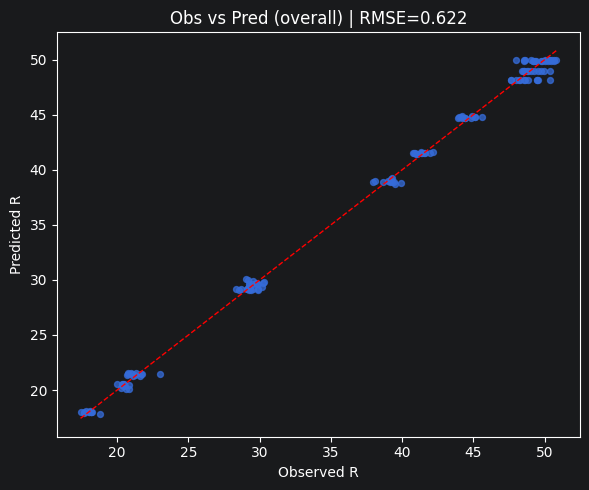

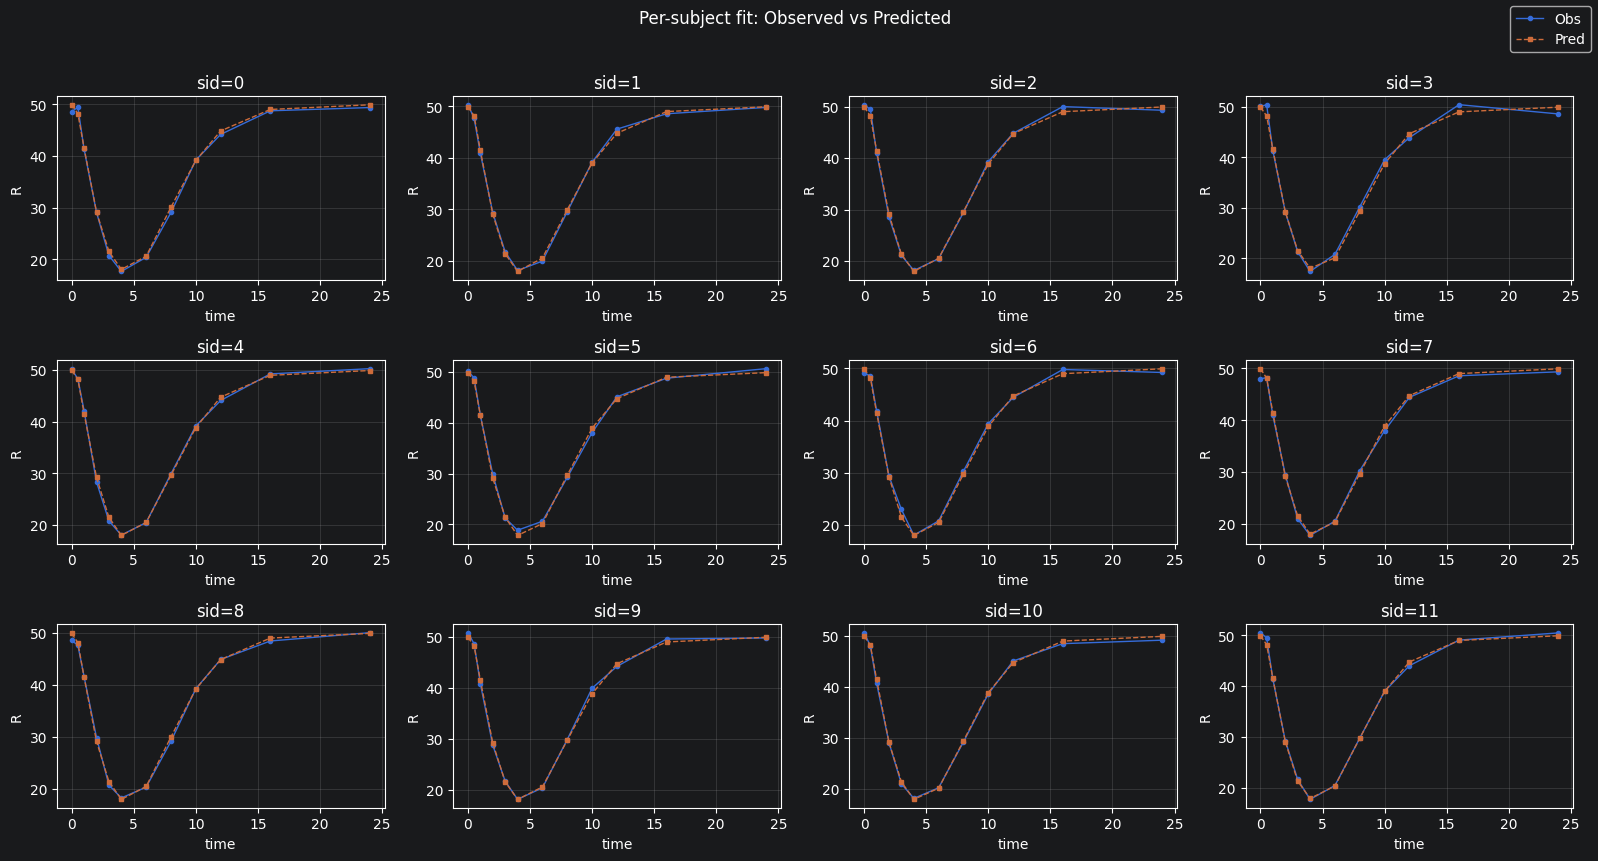

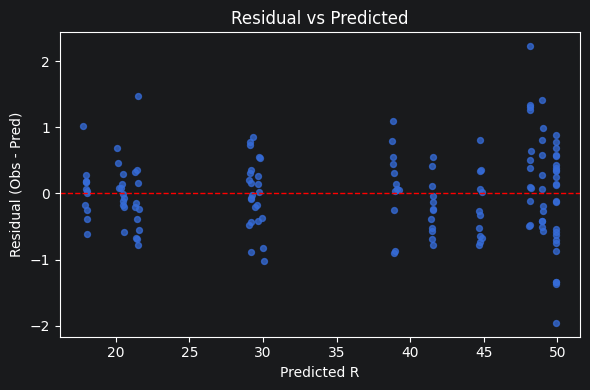

In [28]:
# ============================
# Cell 11: 结果汇总 + 拟合可视化（按受试者分面）
# 前提：已跑完 Cell 10，变量 out / df / tv_pd / eng 存在
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 1) 从 out 提取参数 ----------
est = {
    "Kin":   float(out["Kin_pop"]),
    "Kout":  float(out["Kout_pop"]),
    "EC50":  float(out["EC50"]),
    "Imax":  float(out["Imax"]),
    "gamma": float(out["gamma"]),
}
rmse = float(out["rmse"])
fval = float(out["fval"])

# ---------- 2) 构建汇总表 ----------
rows = []
for p in ["Kin", "Kout", "EC50", "Imax", "gamma"]:
    t = float(tv_pd[p])
    e = float(est[p])
    re = (e - t) / t * 100.0
    rows.append([p, t, e, re])

summary_df = pd.DataFrame(rows, columns=["param", "true", "estimate", "rel_err_%"])
summary_df["abs_rel_err_%"] = summary_df["rel_err_%"].abs()

print("=== Parameter Summary (MATLAB 5-parameter) ===")
display(summary_df)
print(f"RMSE = {rmse:.6f}, SSE(fval) = {fval:.6f}")

# ---------- 3) 在 Python 端用估计参数做预测（与 MATLAB 模型一致） ----------
# 说明：这里用 scipy.odeint，便于直接出图；与 MATLAB ode45 会有微小数值差异
from scipy.integrate import odeint

def pred_subject(tk, ck, Kin, Kout, EC50, Imax, gamma):
    # tk, ck: 1D numpy arrays
    order = np.argsort(tk)
    t_sorted = tk[order]
    c_sorted = ck[order]

    def cfun(tt):
        return np.interp(tt, t_sorted, c_sorted)

    def rhs(R, tt):
        c = max(cfun(tt), 1e-10)
        inhib = (c**gamma) / (EC50**gamma + c**gamma)
        return Kin - (Kin * Imax) * inhib - Kout * R

    R0 = Kin / Kout
    Rsol = odeint(lambda R, tt: rhs(R, tt), R0, t_sorted).ravel()

    y = np.empty_like(Rsol)
    y[order.argsort()] = Rsol
    return y

df_plot = df.copy()
df_plot["sid_plot"] = df_plot["sid"].astype(int)

pred_all = np.zeros(len(df_plot), dtype=float)
for sid_i, g in df_plot.groupby("sid_plot"):
    idx = g.index.values
    tk = g["time"].values.astype(float)
    ck = g["C_obs"].values.astype(float)

    pred_all[idx] = pred_subject(
        tk, ck,
        est["Kin"], est["Kout"], est["EC50"], est["Imax"], est["gamma"]
    )

df_plot["R_pred"] = pred_all
df_plot["resid"] = df_plot["R_obs"] - df_plot["R_pred"]

# ---------- 4) 总体拟合图 ----------
plt.figure(figsize=(6,5))
plt.scatter(df_plot["R_obs"], df_plot["R_pred"], s=18, alpha=0.75)
mn = min(df_plot["R_obs"].min(), df_plot["R_pred"].min())
mx = max(df_plot["R_obs"].max(), df_plot["R_pred"].max())
plt.plot([mn, mx], [mn, mx], "r--", lw=1)
plt.xlabel("Observed R")
plt.ylabel("Predicted R")
plt.title(f"Obs vs Pred (overall) | RMSE={rmse:.3f}")
plt.tight_layout()
plt.show()

# ---------- 5) 按受试者分面：时间-响应 ----------
subs = sorted(df_plot["sid_plot"].unique())
n = len(subs)
ncol = 4
nrow = int(np.ceil(n / ncol))

fig, axes = plt.subplots(nrow, ncol, figsize=(4*ncol, 2.8*nrow), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for i, sid_i in enumerate(subs):
    ax = axes[i]
    g = df_plot[df_plot["sid_plot"] == sid_i].sort_values("time")
    ax.plot(g["time"], g["R_obs"], "o-", ms=3, lw=1, label="Obs")
    ax.plot(g["time"], g["R_pred"], "s--", ms=3, lw=1, label="Pred")
    ax.set_title(f"sid={sid_i}")
    ax.set_xlabel("time")
    ax.set_ylabel("R")
    ax.grid(alpha=0.25)

# 清理多余子图
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Per-subject fit: Observed vs Predicted", y=1.02)
plt.tight_layout()
plt.show()

# ---------- 6) 残差诊断 ----------
plt.figure(figsize=(6,4))
plt.scatter(df_plot["R_pred"], df_plot["resid"], s=18, alpha=0.75)
plt.axhline(0, color="r", linestyle="--", lw=1)
plt.xlabel("Predicted R")
plt.ylabel("Residual (Obs - Pred)")
plt.title("Residual vs Predicted")
plt.tight_layout()
plt.show()